In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("P2Deliverable2_raw.csv")
df.sample(5)

,X,Y,OBJECTID,NCESSCH,SURVYEAR,STABR,LEAID,ST_LEAID,LEA_NAME,SCH_NAME,...,TRALM,TRALF,TR,WHALM,WHALF,WH,LATCOD,LONCOD,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
32882,-93.003798,43.147745,34364,192076001236,2022-2023,IA,1920760,IA-984772 000,Central Springs Comm School District,Central Springs Middle School,...,4.0,3.0,7.0,133.0,119.0,252.0,43.147745,-93.003798,False,True
43395,-85.830234,42.170464,44972,262124005848,2022-2023,MI,2621240,MI-80140,Lawton Community School District,Lawton Middle School,...,7.0,15.0,22.0,122.0,117.0,239.0,42.170464,-85.830234,True,True
40069,-71.340195,42.674917,41607,250432001625,2022-2023,MA,2504320,MA-0079,Dracut,Justus C. Richardson Middle School,...,9.0,7.0,16.0,299.0,271.0,570.0,42.674917,-71.340195,False,True
77209,-98.261403,43.715395,79041,464965000454,2022-2023,SD,4649650,SD-17003,Mount Vernon School District 17-3,Mount Vernon Elementary - 02,...,0.0,1.0,1.0,47.0,65.0,112.0,43.715395,-98.261403,True,True
28470,-87.694300,38.718800,29911,172215004560,2022-2023,IL,1722150,IL-12-051-0200-26,Lawrence County CUD 20,Parkside Elementary School,...,17.0,11.0,28.0,239.0,214.0,453.0,38.718800,-87.694300,True,True


--- Statistics for LSTATE ---
Label Mapping: {'AK': np.int64(0), 'AL': np.int64(1), 'AR': np.int64(2), 'AZ': np.int64(3), 'CA': np.int64(4), 'CO': np.int64(5), 'CT': np.int64(6), 'DC': np.int64(7), 'DE': np.int64(8), 'FL': np.int64(9), 'GA': np.int64(10), 'HI': np.int64(11), 'IA': np.int64(12), 'ID': np.int64(13), 'IL': np.int64(14), 'IN': np.int64(15), 'KS': np.int64(16), 'KY': np.int64(17), 'LA': np.int64(18), 'MA': np.int64(19), 'MD': np.int64(20), 'ME': np.int64(21), 'MI': np.int64(22), 'MN': np.int64(23), 'MO': np.int64(24), 'MP': np.int64(25), 'MS': np.int64(26), 'MT': np.int64(27), 'NC': np.int64(28), 'ND': np.int64(29), 'NE': np.int64(30), 'NH': np.int64(31), 'NJ': np.int64(32), 'NM': np.int64(33), 'NV': np.int64(34), 'NY': np.int64(35), 'OH': np.int64(36), 'OK': np.int64(37), 'OR': np.int64(38), 'PA': np.int64(39), 'PR': np.int64(40), 'RI': np.int64(41), 'SC': np.int64(42), 'SD': np.int64(43), 'TN': np.int64(44), 'TX': np.int64(45), 'UT': np.int64(46), 'VA': np.int64(47), 'VI'

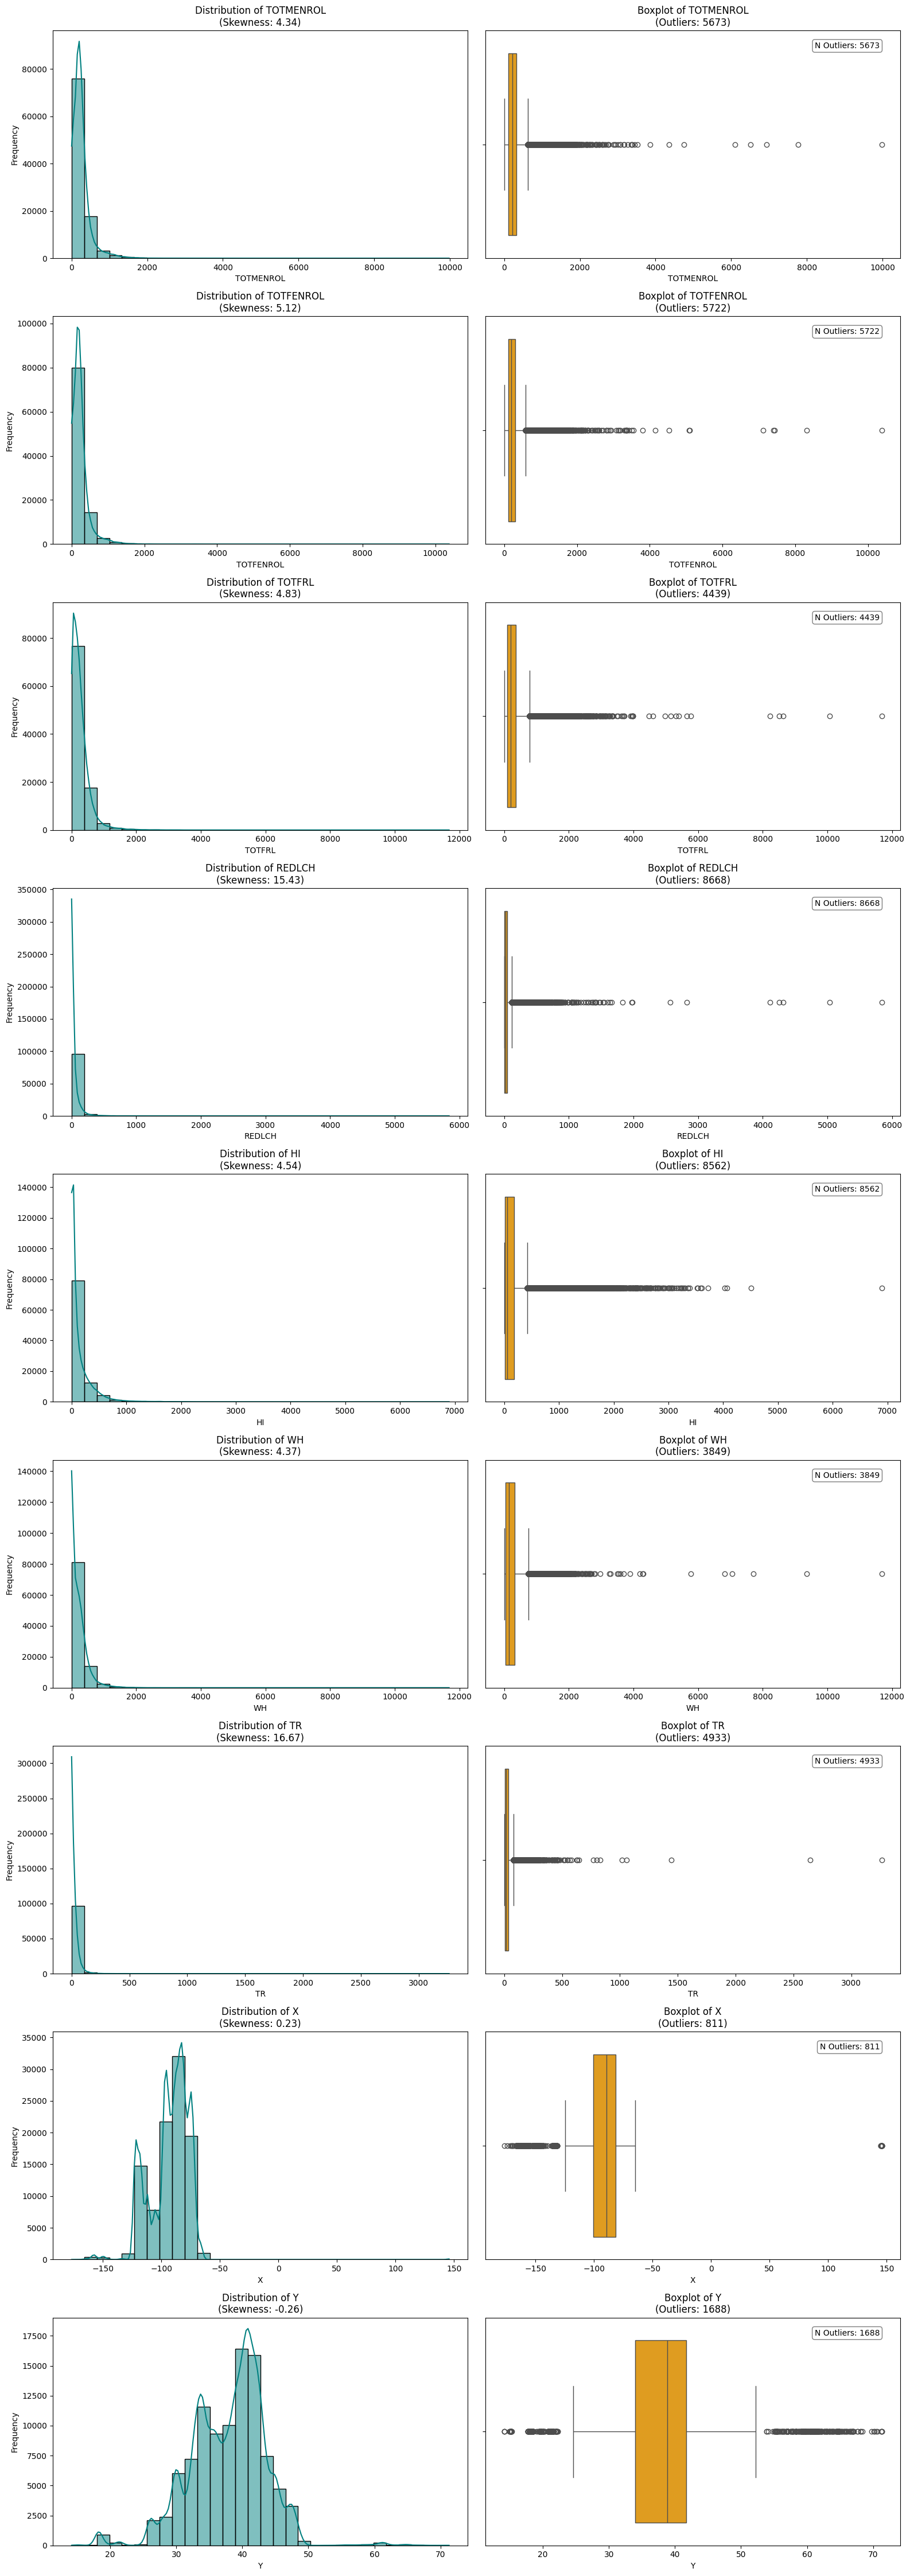

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

cols = ['LSTATE', 'X', 'Y', 'TOTMENROL', 'TOTFENROL', 'TOTFRL', 'HI', 'SCHOOL_TYPE_TEXT', 'WH', 'REDLCH', 'TR', 'SCHOOL_LEVEL', 'GSHI']
cat_cols = ['LSTATE', 'SCHOOL_TYPE_TEXT', 'SCHOOL_LEVEL', 'GSHI']
num_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL','REDLCH','HI', 'WH', 'TR', 'X', 'Y']
le = LabelEncoder()

X = df[cols]

Y = df['STUTERATIO']
# --- Categorical Columns: Mappings and Raw Counts (Least to Most) ---
for col in cat_cols:
    # Fitting the encoder to show the user what the numbers represent
    X[col] = le.fit_transform(X[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    print(f"--- Statistics for {col} ---")
    print(f"Label Mapping: {mapping}")
    
    # .value_counts(ascending=True) sorts by frequency (rarest first)
    # We remove normalize=True to get actual numbers
    print("Actual Counts (Least to Most):")
    print(df[col].value_counts(ascending=True))
    print("-" * 40)

# --- Numerical Distribution & Boxplots with Outlier Counts ---
# Creating 2 columns: Histograms on left, Boxplots on right
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(16, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
    # 1. Calculate Outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count rows outside the bounds
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    skew_val = df[col].skew()
    
    # 2. Plot Histogram (KDE)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}\n(Skewness: {skew_val:.2f})')
    axes[i, 0].set_ylabel('Frequency')

    # 3. Plot Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'Boxplot of {col}\n(Outliers: {outliers_count})')
    
    # Optional: Annotate the outlier count directly on the plot
    axes[i, 1].text(0.95, 0.95, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

## Task 1. Data Balancing
Choose between the Original Data or Transformed Data.  
N.B. Test only on the original test set, not on the balanced/transformed dataset.

### b. Handling Outliers & Unequal Variance for Regression:

##### Normalization

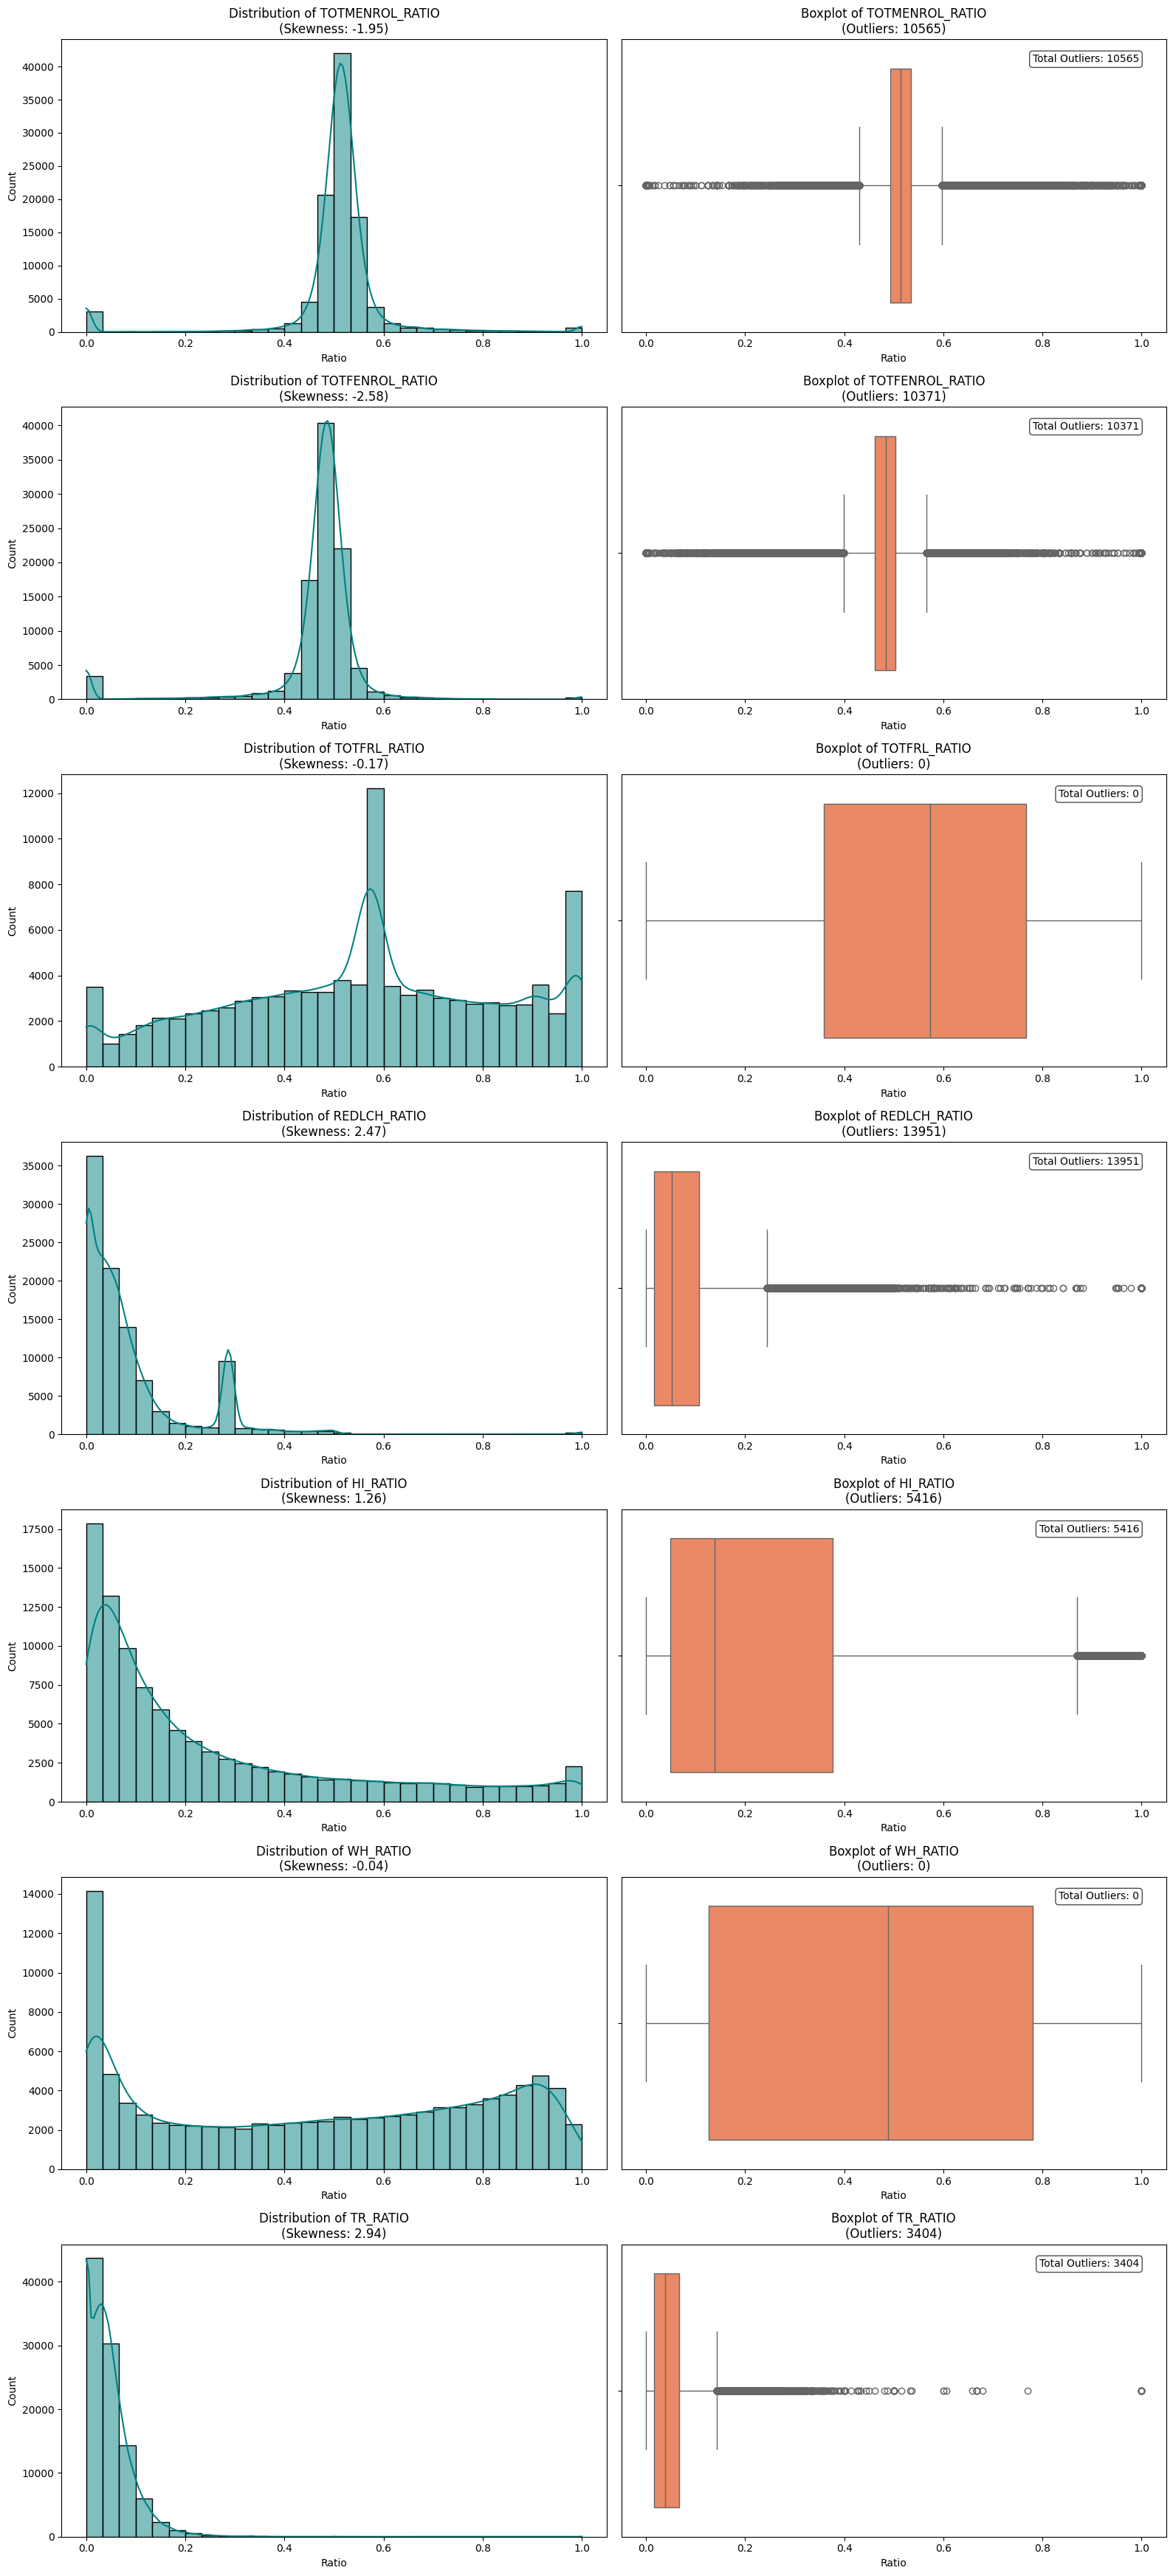

,LSTATE,X,Y,TOTMENROL,TOTFENROL,TOTFRL,HI,SCHOOL_TYPE_TEXT,WH,REDLCH,TR,SCHOOL_LEVEL,GSHI,TOTMENROL_RATIO,TOTFENROL_RATIO,TOTFRL_RATIO,REDLCH_RATIO,HI_RATIO,WH_RATIO,TR_RATIO
90083,47,-79.034900,38.030000,220.0,231.0,193.0,18.0,2,372.0,22.0,37.0,0,4,0.487805,0.512195,0.427938,0.048780,0.039911,0.824834,0.082040
96645,51,-87.808279,42.741388,335.0,360.0,375.0,226.0,2,280.0,0.0,71.0,0,7,0.482014,0.517986,0.539568,0.000000,0.325180,0.402878,0.102158
18386,9,-85.674677,30.169470,87.0,108.0,121.0,64.0,2,85.0,6.0,15.0,1,11,0.446154,0.553846,0.620513,0.030769,0.328205,0.435897,0.076923
10419,4,-121.986729,36.983729,167.0,148.0,158.0,158.0,2,129.0,16.0,9.0,0,4,0.530159,0.469841,0.501587,0.050794,0.501587,0.409524,0.028571
36870,18,-90.073710,29.895895,219.0,197.0,312.0,146.0,2,25.0,0.0,11.0,0,4,0.526442,0.473558,0.750000,0.000000,0.350962,0.060096,0.026442


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

count_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR']

# 1. Create ratio columns
for col in count_cols:
    # Use .div() to handle division and avoid errors if TOTAL is 0
    X[f'{col}_RATIO'] = X[col] / df['TOTAL']

# Fill any resulting NaNs with 0
ratio_cols = [f'{c}_RATIO' for c in count_cols]
X[ratio_cols] = X[ratio_cols].fillna(0)

# 2. Setup the plotting grid: 7 rows (for each column), 2 columns (Hist vs Box)
fig, axes = plt.subplots(nrows=len(count_cols), ncols=2, figsize=(16, 5 * len(count_cols)))

for i, col in enumerate(count_cols):
    ratio_col = f'{col}_RATIO'
    data = X[ratio_col]
    
    # --- Calculate Outliers using IQR Method ---
    # $Q1$ is the 25th percentile, $Q3$ is the 75th percentile
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count data points outside the bounds
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    skew_val = data.skew()

    # --- Plot 1: Histogram (KDE) ---
    sns.histplot(data, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {ratio_col}\n(Skewness: {skew_val:.2f})', fontsize=12)
    axes[i, 0].set_xlabel('Ratio')

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Boxplot of {ratio_col}\n(Outliers: {outliers_count})', fontsize=12)
    axes[i, 1].set_xlabel('Ratio')
    
    # Add an annotation box inside the plot for the outlier count
    axes[i, 1].text(0.95, 0.95, f'Total Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Adjust layout to prevent overlapping titles/axes
plt.tight_layout()
plt.show()

# Show sample of updated DataFrame
X.sample(5)

##### Log Tranformation

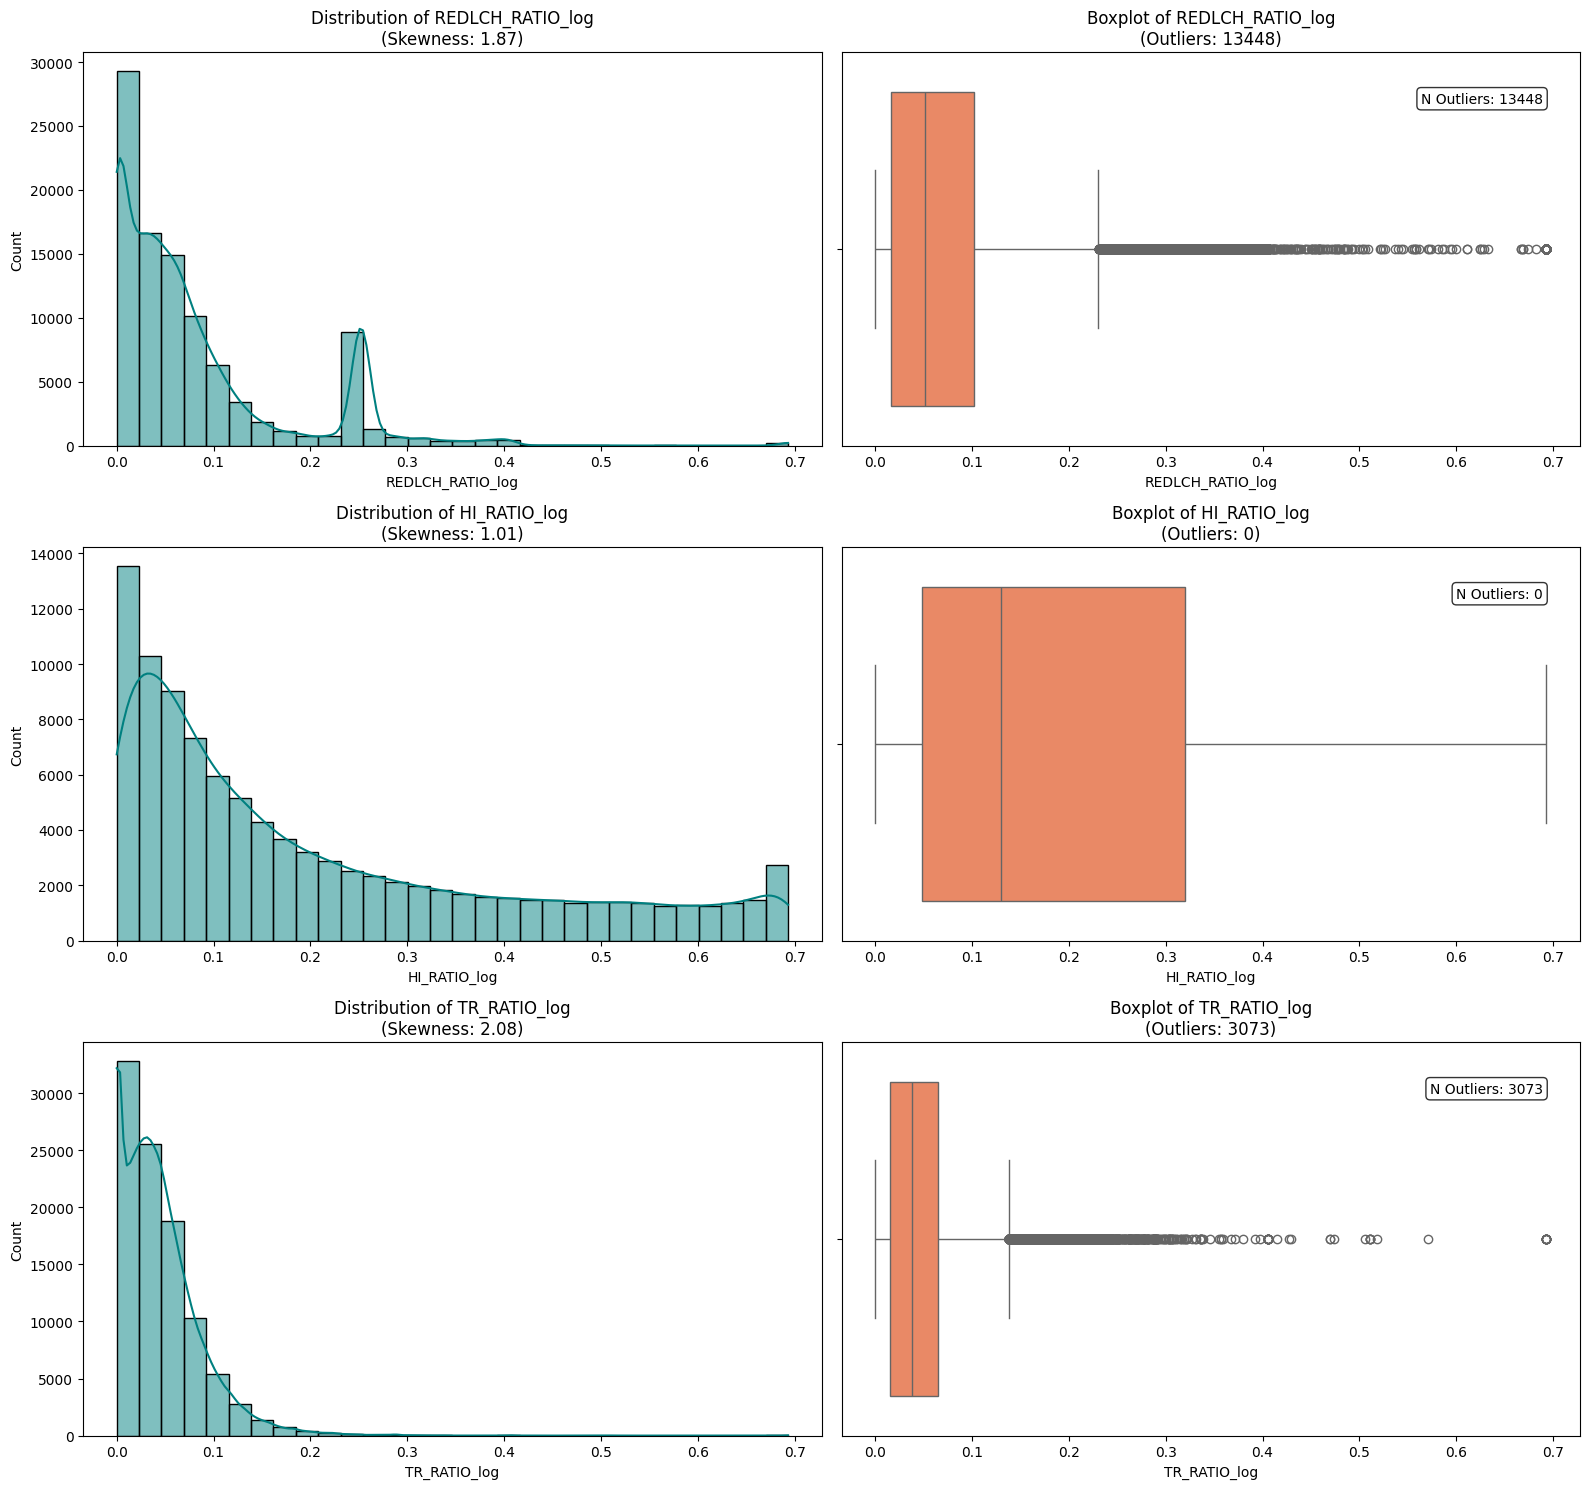

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

log_cols_base = ['REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']
log_cols_final = [f'{col}_log' for col in log_cols_base]

# 1. Apply transformations (keeping it here for completeness)
for col in log_cols_base:
    X[f'{col}_log'] = np.log1p(X[col])

# 2. Setup Plotting: 3 rows (one per variable), 2 columns (Dist vs Box)
fig, axes = plt.subplots(nrows=len(log_cols_final), ncols=2, figsize=(16, 5 * len(log_cols_final)))

for i, col in enumerate(log_cols_final):
    data = X[col]
    
    # --- Calculate Outliers (IQR Method) ---
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    
    skew_val = data.skew()

    # --- Plot 1: Histogram ---
    sns.histplot(data, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}\n(Skewness: {skew_val:.2f})', fontsize=12)

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Boxplot of {col}\n(Outliers: {outliers_count})', fontsize=12)
    
    # Add a visual label for the outlier count
    axes[i, 1].text(0.95, 0.9, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

##### Robust Scaler

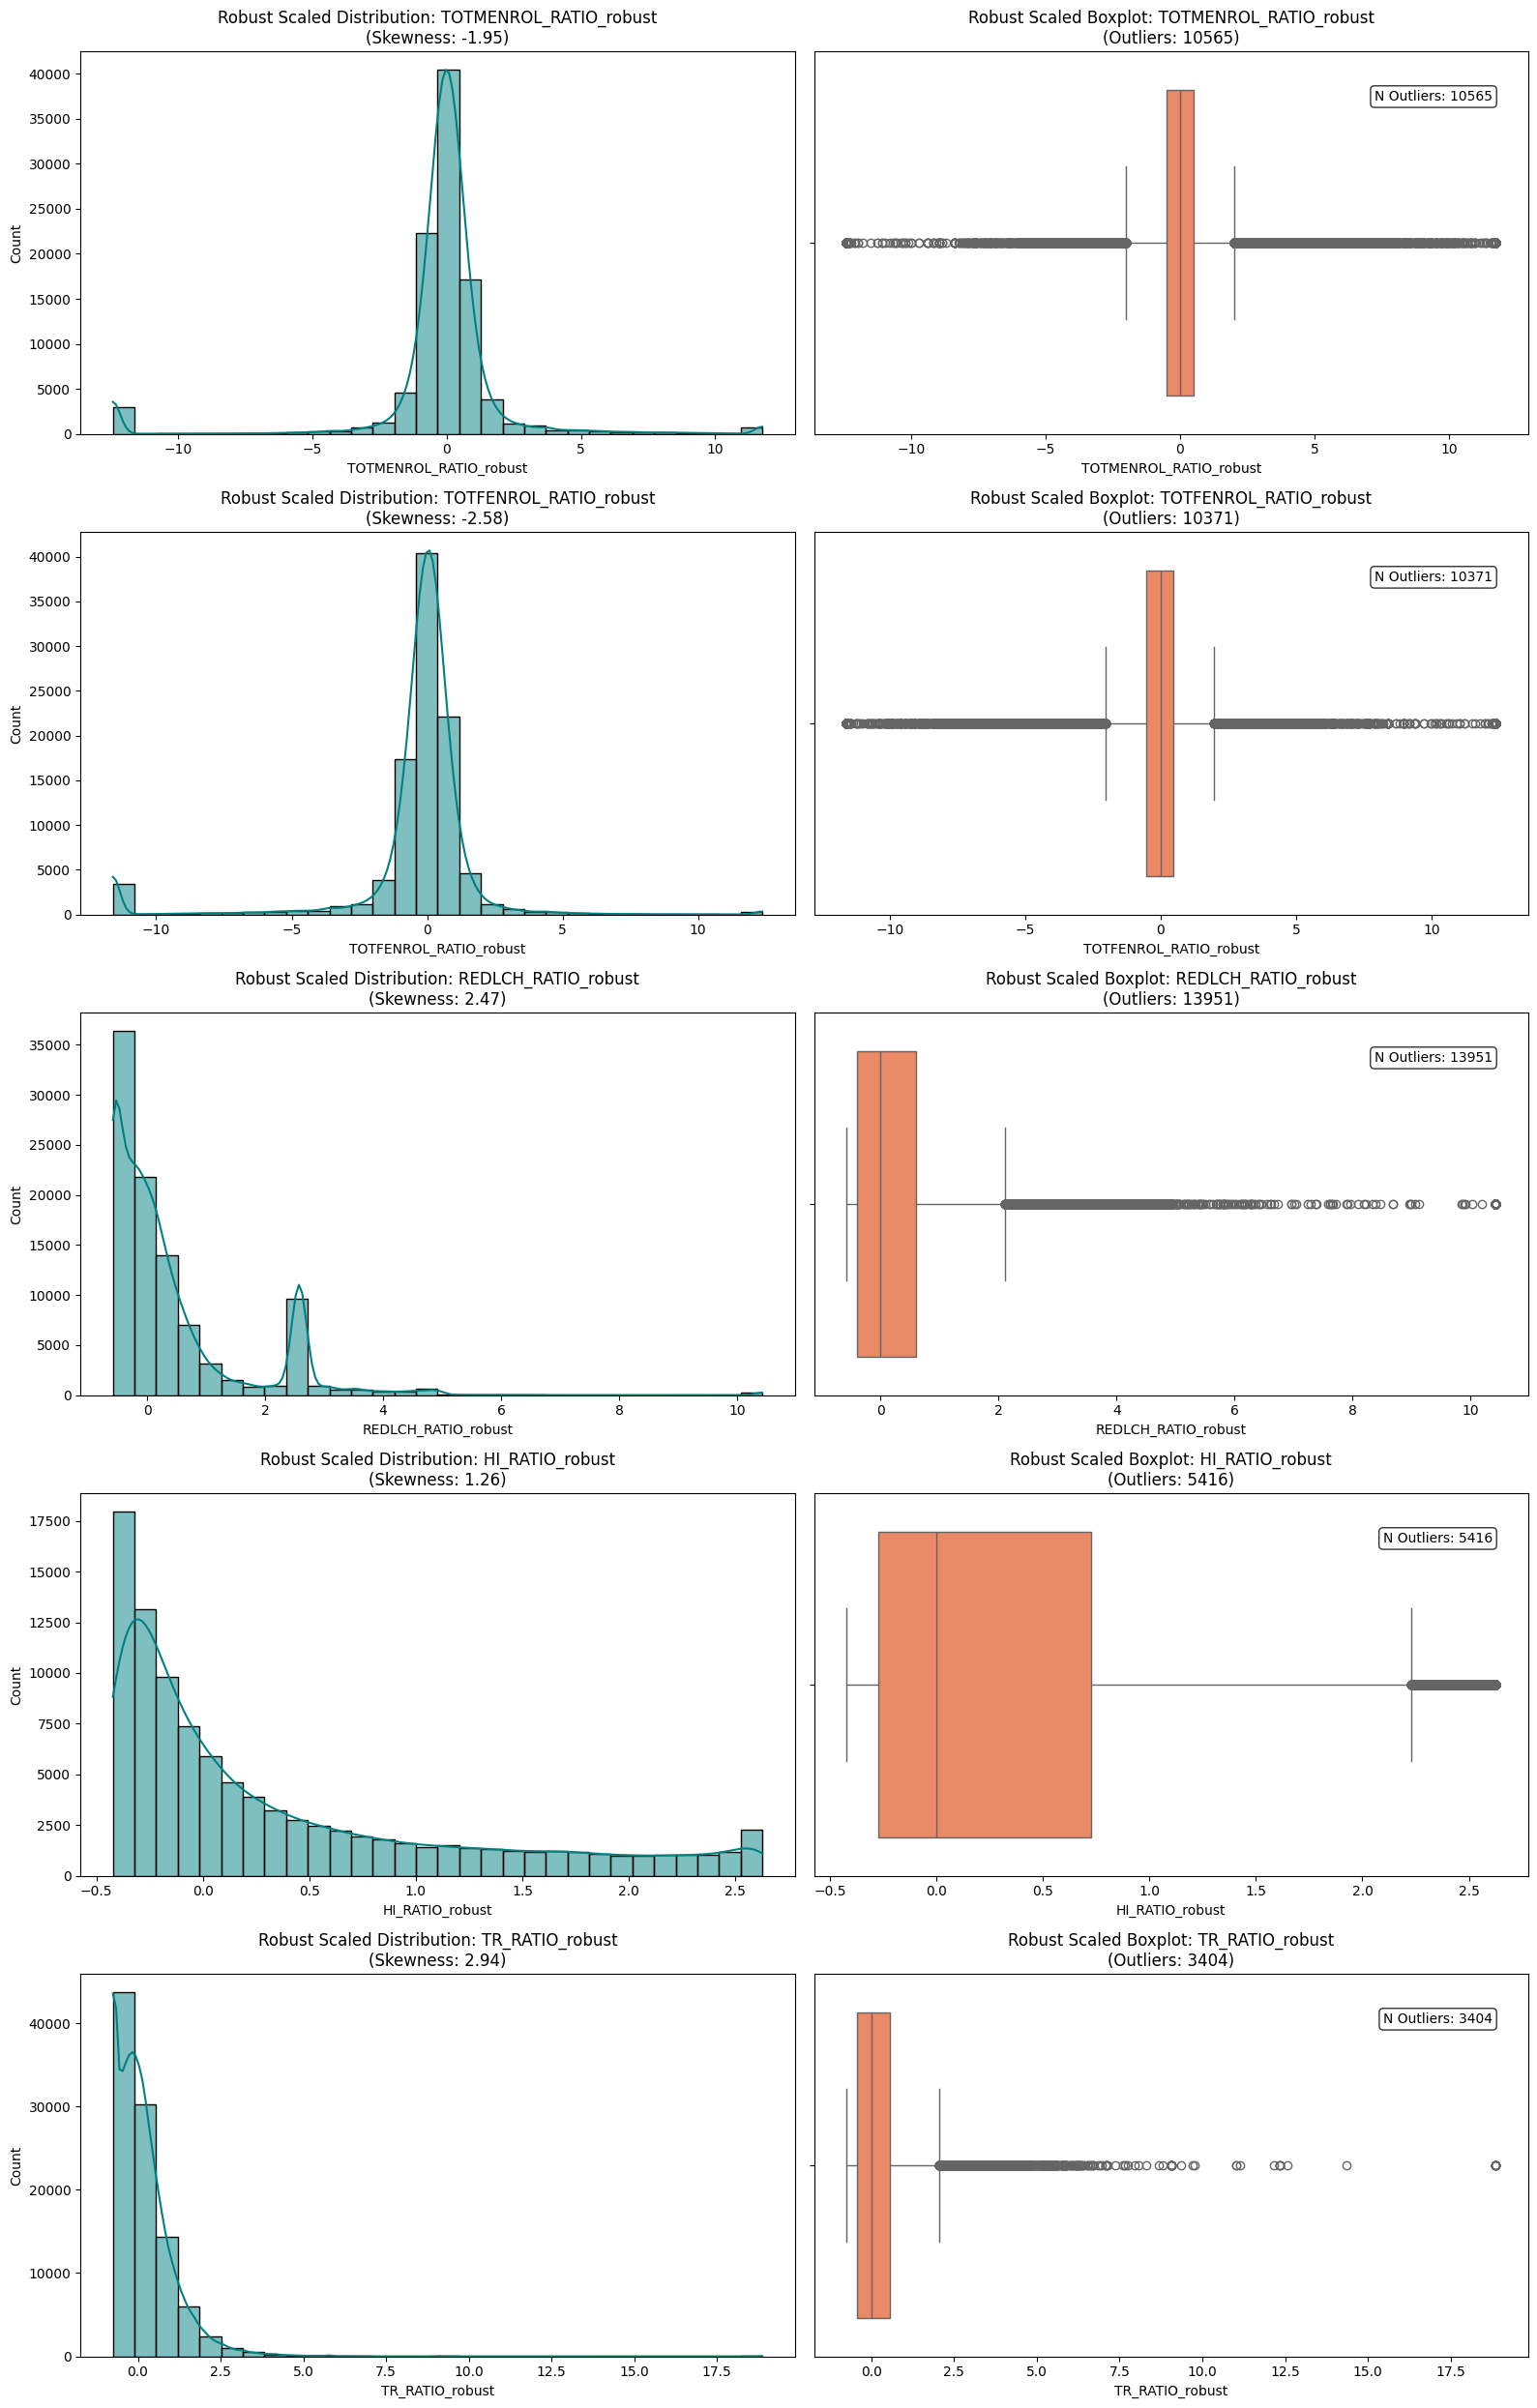

In [6]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns you want to scale
# You can use the original ratios or your log/bc transformed ones
robust_cols = ['TOTMENROL_RATIO', 'TOTFENROL_RATIO', 'REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']

scaler = RobustScaler()

# Apply the scaling
# We create new column names to keep track
for col in robust_cols:
    X[f'{col}_robust'] = scaler.fit_transform(X[[col]])

# Setup plotting for the new robust columns
fig, axes = plt.subplots(nrows=len(robust_cols), ncols=2, figsize=(16, 5 * len(robust_cols)))

for i, col in enumerate(robust_cols):
    robust_col = f'{col}_robust'
    data = X[robust_col]
    
    # Calculate Outliers using IQR for the scaled data
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    
    skew_val = data.skew()

    # --- Plot 1: Histogram ---
    sns.histplot(data, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Robust Scaled Distribution: {robust_col}\n(Skewness: {skew_val:.2f})')

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Robust Scaled Boxplot: {robust_col}\n(Outliers: {outliers_count})')
    
    # Add annotation box
    axes[i, 1].text(0.95, 0.9, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

##### Binning

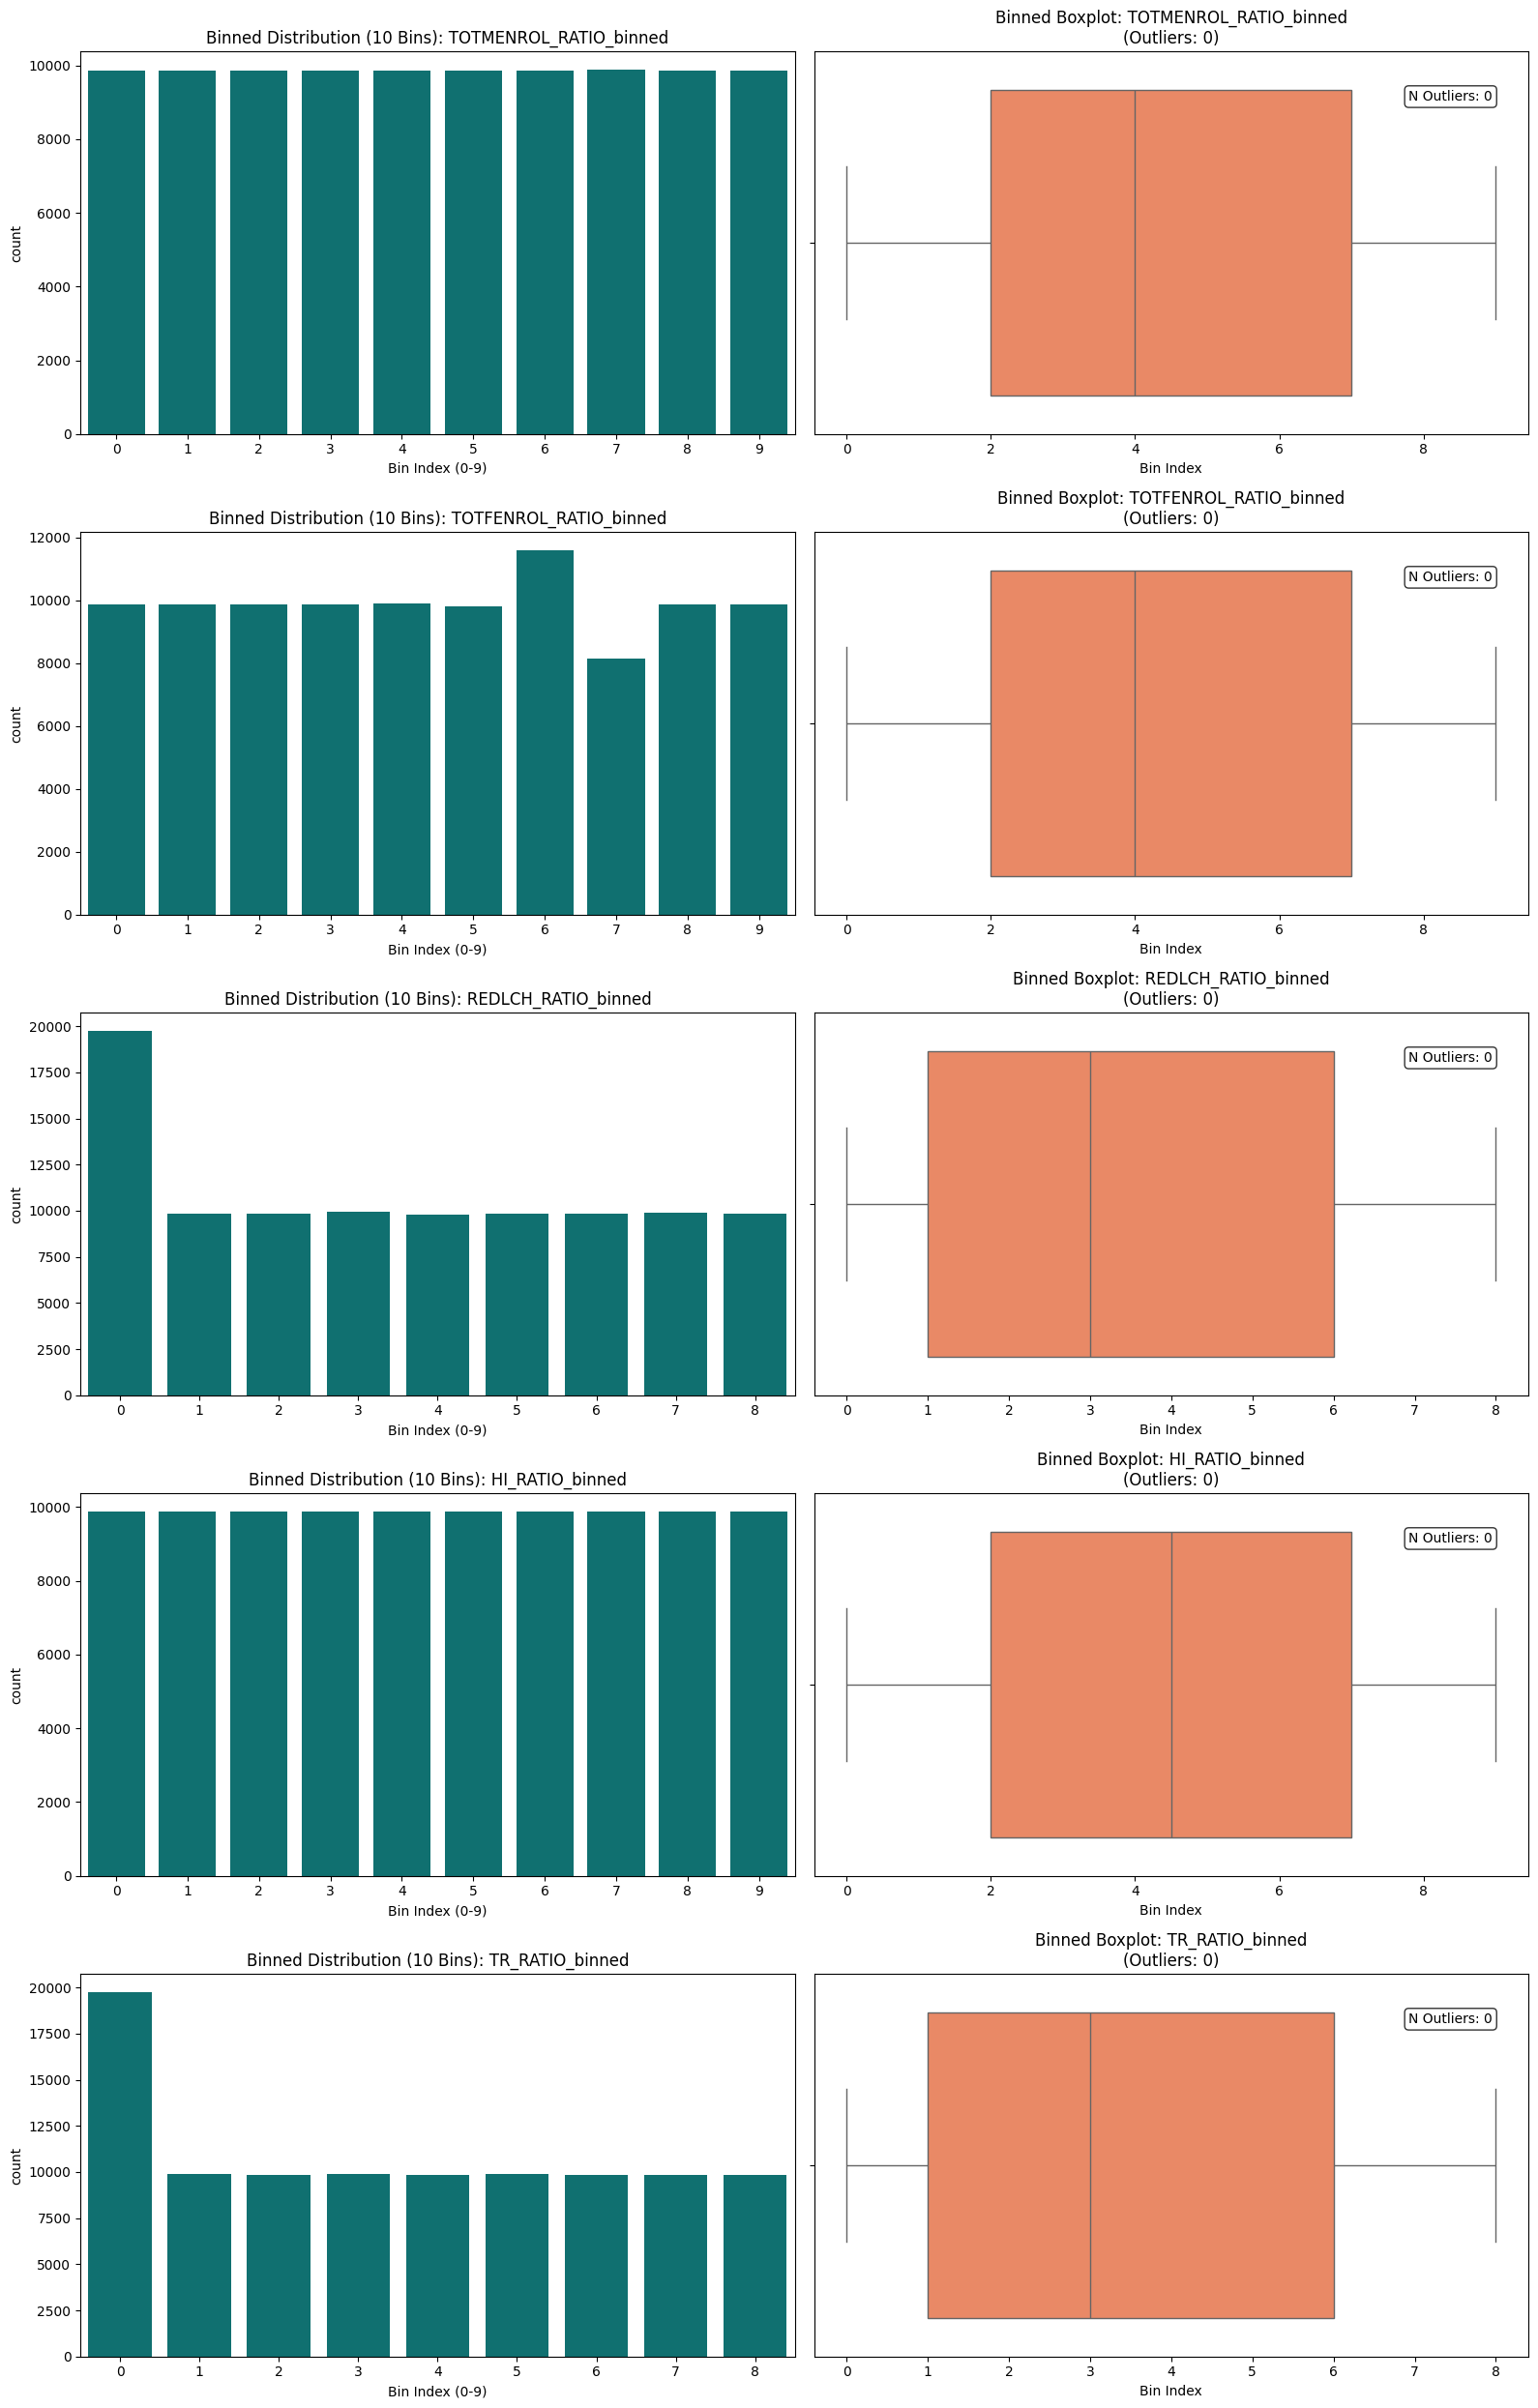

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to bin
bin_cols = ['TOTMENROL_RATIO', 'TOTFENROL_RATIO', 'REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']

for col in bin_cols:
    # pd.qcut creates 10 equal-sized bins (deciles)
    # labels=False returns integer codes 0-9 instead of interval strings
    # duplicates='drop' handles cases where many values are identical (like 0.0)
    X[f'{col}_binned'] = pd.qcut(X[col], q=10, labels=False, duplicates='drop')

# Setup plotting for the new binned columns
fig, axes = plt.subplots(nrows=len(bin_cols), ncols=2, figsize=(16, 5 * len(bin_cols)))

for i, col in enumerate(bin_cols):
    binned_col = f'{col}_binned'
    data = X[binned_col]
    
    # Calculate Outliers using IQR (Expected to be 0 for binned data)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    
    # --- Plot 1: Countplot (Better than Histplot for discrete bins) ---
    sns.countplot(x=data, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Binned Distribution (10 Bins): {binned_col}')
    axes[i, 0].set_xlabel('Bin Index (0-9)')

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Binned Boxplot: {binned_col}\n(Outliers: {outliers_count})')
    axes[i, 1].set_xlabel('Bin Index')
    
    # Add annotation box
    axes[i, 1].text(0.95, 0.9, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

#### Before vs After Performance

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np
import pandas as pd

# Define column groups
count_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR']
ratio_cols = [f'{c}_RATIO' for c in count_cols]
log_target_cols = ['REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']
geo_cols = ['X', 'Y']

# 1. Baseline: Raw Counts
features_baseline = count_cols + geo_cols

# 2. Step 1: Normalization (Standard Scaling of raw counts)
X_norm = X.copy()
scaler_std = StandardScaler()
X_norm[count_cols] = scaler_std.fit_transform(X_norm[count_cols])
features_norm = count_cols + geo_cols

# 3. Step 2: Log Transformation (Applying log to the ratios)
X_log = X.copy()
for col in log_target_cols:
    X_log[f'{col}_log'] = np.log1p(X_log[col])
# For this set, we'll use the logged ratios + original ratios for the others
features_log = [f'{c}_log' if c in log_target_cols else c for c in ratio_cols] + geo_cols

# 4. Step 3: Robust Scaling (Applying Robust to all ratios)
X_robust = X.copy()
scaler_robust = RobustScaler()
X_robust[ratio_cols] = scaler_robust.fit_transform(X_robust[ratio_cols])
features_robust = ratio_cols + geo_cols

# 5. Step 4: Binning (Quantile binning into 10 categories)
X_bin = X.copy()
for col in ratio_cols:
    X_bin[f'{col}_bin'] = pd.qcut(X_bin[col], q=10, labels=False, duplicates='drop')
features_bin = [f'{c}_bin' for c in ratio_cols] + geo_cols

def evaluate_model(features_df, target, label):
    X_train, X_test, y_train, y_test = train_test_split(features_df, target, test_size=0.3, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    
    return {
        'Step': label,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }

# Execute comparisons
results = []
results.append(evaluate_model(X[features_baseline], Y, "1. Baseline (Raw Counts)"))
results.append(evaluate_model(X_norm[features_norm], Y, "2. Normalized Raw Counts"))
results.append(evaluate_model(X_log[features_log], Y, "3. Log Transformed Ratios"))
results.append(evaluate_model(X_robust[features_robust], Y, "4. Robust Scaled Ratios"))
results.append(evaluate_model(X_bin[features_bin], Y, "5. Binned Ratios (10 Bins)"))

# Display performance table
performance_df = pd.DataFrame(results)
print("\n--- Performance Comparison Table ---")
print(performance_df.to_string(index=False))


--- Performance Comparison Table ---
                      Step      MAE     RMSE       R2
  1. Baseline (Raw Counts) 2.542676 4.511108 0.399596
  2. Normalized Raw Counts 2.542942 4.512058 0.399343
 3. Log Transformed Ratios 2.688711 4.586580 0.379338
   4. Robust Scaled Ratios 2.688716 4.586452 0.379373
5. Binned Ratios (10 Bins) 2.741765 4.658948 0.359598


#### Trade-Off

- Normalization: Remove scale bias, good for SVR, makes features comparable but doesn't fix skew + lose size info
- Log Transform: fix skew/variance, but compresses high end differences (similar at extreme)
- Robust Scaling: Immune to outliers, but skew stays. just recenters
- Quantile Binning: Removes outliers/skewness, but loses continuity - low R^2. if same bin then treated the same

## Task 2. Hyperparameter Explanation

### Identify key hyperparameters

In [9]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

base_features = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR', 'X', 'Y']
all_features = cat_cols + base_features 
# IMPORTANT: SVR requires scaling for all features to work correctly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[all_features])

# Split with the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42)

# --- 1. Support Vector Regression (SVR) ---
# Tuning 'C': Regularization parameter (higher C means less regularization)
# Tuning 'epsilon': Specifies the "tube" within which no penalty is associated in the training loss
# Tuning 'kernel': 'rbf' is usually best for non-linear data; 'linear' is closer to Ridge
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1) 
svr_model.fit(X_train, y_train)
svr_preds = svr_model.predict(X_test)

# --- 2. Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# --- 3. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=200, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Helper Function to Print Results ---
def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}\n")

print_metrics("SVR (Kernel=RBF, C=1.0)", y_test, svr_preds)
print_metrics("Decision Tree (max_depth=5)", y_test, dt_preds)
print_metrics("Random Forest (n_estimators=200)", y_test, rf_preds)

--- SVR (Kernel=RBF, C=1.0) ---
MAE: 2.6199 | RMSE: 4.6491 | R2: 0.3623

--- Decision Tree (max_depth=5) ---
MAE: 2.9558 | RMSE: 4.8128 | R2: 0.3166

--- Random Forest (n_estimators=200) ---
MAE: 2.2867 | RMSE: 4.1281 | R2: 0.4972



## Task 3. Hyperparameter Tuning (Grid Search)
• At least 5–10 parameter combinations for Grid Search  
• Cross-validation = minimum 5-fold

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# 1. Define Parameter Grids
# SVR Params: 
# 'C' is the penalty for error (higher = strict), 
# 'epsilon' is the width of the "no-penalty" tube.
svr_params = {
    'C': [0.1, 1, 10], 
    'epsilon': [0.01, 0.1],
    'kernel': ['rbf'] # RBF is generally the best starting point for non-linear data
}

dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 10, 20]
}

rf_params = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'], # Removed None to speed up RF
    'max_depth': [10, 20]
}

# 2. Initialize Models (Replacing Ridge with SVR)
models = [
    ('SVR', SVR(), svr_params),
    ('Decision Tree', DecisionTreeRegressor(random_state=42), dt_params),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), rf_params)
]

# 3. Run GridSearch
tuned_results = []

for name, model, params in models:
    print(f"Tuning {name}...")
    # Using neg_mean_absolute_error because GridSearchCV maximizes scores
    grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    # Ensure X_train is the SCALED version we created earlier!
    grid.fit(X_train, y_train) 
    
    # Get best model and predict
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    tuned_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
# 4. Display Results
tuned_df = pd.DataFrame(tuned_results)
print("\n--- Final Tuned Results ---")
print(tuned_df[['Model', 'MAE', 'RMSE', 'R2']])

print("\nDetailed Best Parameters:")
for res in tuned_results:
    print(f"{res['Model']}: {res['Best Params']}")

Tuning SVR...
Tuning Decision Tree...
Tuning Random Forest...

--- Final Tuned Results ---
           Model       MAE      RMSE        R2
0            SVR  2.507959  4.517346  0.397935
1  Decision Tree  2.660977  4.650882  0.361813
2  Random Forest  2.311568  4.136095  0.495271

Detailed Best Parameters:
SVR: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
Decision Tree: {'max_depth': 10, 'min_samples_split': 20}
Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}


## Task 4. Model Evaluation & Best Model Selection

TUNED MODEL COMPARISON
-----------------------------------------------------------------
        Model                                                    Best Params      MAE     RMSE       R2
Random Forest {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200} 2.311568 4.136095 0.495271
          SVR                     {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'} 2.507959 4.517346 0.397935
Decision Tree                     {'max_depth': 10, 'min_samples_split': 20} 2.660977 4.650882 0.361813

BEST MODEL: Random Forest (Lowest MAE, Lowest RMSE, Highest R²)


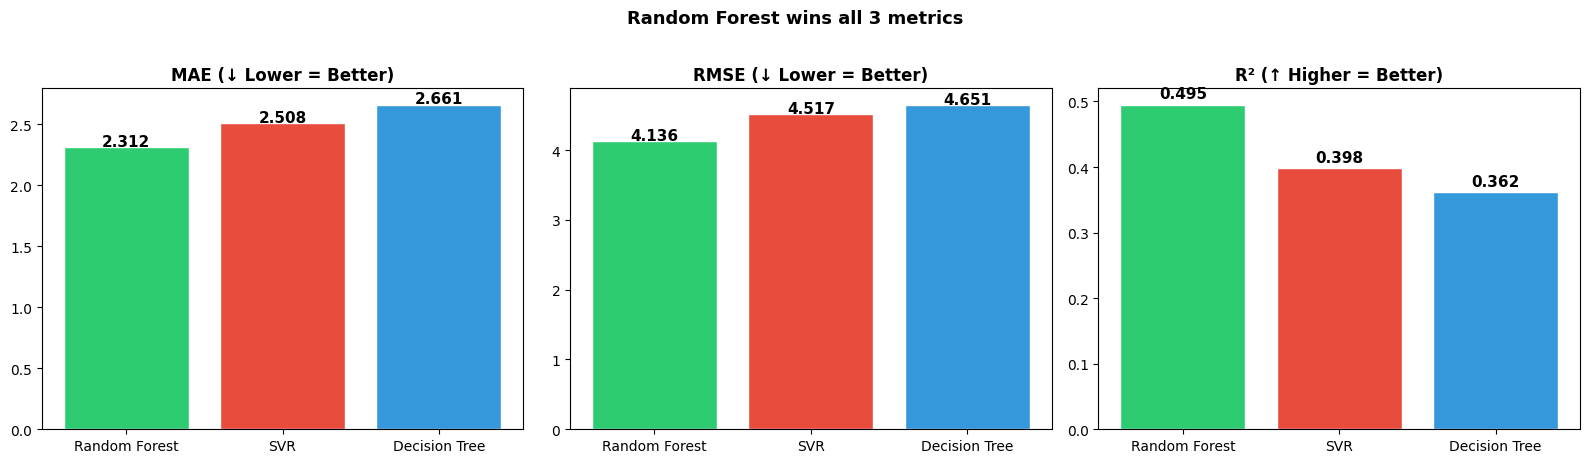

DELIVERABLE 1 vs DELIVERABLE 2
-----------------------------------------------------------------
        Model  D1 R²           D1 Params  D2 R²                 D2 Params  Gain
Decision Tree  0.257             depth=5  0.362        depth=10, split=20 0.105
          SVR  0.337            C=1, rbf  0.398          C=10, ε=0.1, rbf 0.061
Random Forest  0.389 100 trees, depth=10  0.495 200 trees, sqrt, depth=20 0.106


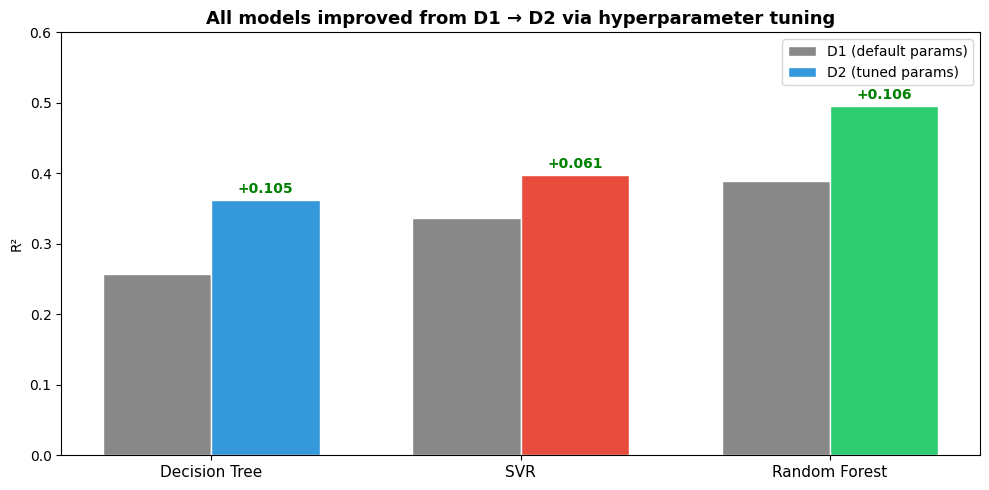

WHY RANDOM FOREST WON
-----------------------------------------------------------------
  • 200 trees averaging - individual mistakes cancel out
  • Handles categorical + numerical features
  • splits by rank ordering, not distance
  • Captures complex interactions (geography, demographics, school type)

WHY SVR WAS IN THE MIDDLE
----------------------------------------
  • RBF kernel captures non-linear patterns
  • BUT: 54 encoded LSTATE values dimensionality
  • Distance-based model struggles in high dimensions

WHY DECISION TREE WAS WORST
----------------------------------------
  • Single tree → no ensemble averaging to cancel errors
  • High variance: small data change → completely different tree
  • depth=10 → max 1,024 leaves for ~95K diverse schools

EVALUATION TRADE-OFF: MAE vs RMSE
-----------------------------------------------------------------
        Model   MAE  RMSE  Gap (RMSE-MAE)
Random Forest 2.311 4.136           1.825
          SVR 2.508 4.517           2.009
Deci

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. SUMMARY TABLE
summary = pd.DataFrame(tuned_results)[['Model', 'Best Params', 'MAE', 'RMSE', 'R2']]
summary = summary.sort_values('R2', ascending=False)
print("TUNED MODEL COMPARISON")
print("-" * 65)
print(summary.to_string(index=False))
print("\nBEST MODEL: Random Forest (Lowest MAE, Lowest RMSE, Highest R²)")

# 2. METRIC COMPARISON CHART
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
models_list = summary['Model'].tolist()
colors = {'Random Forest': '#2ecc71', 'SVR': '#e74c3c', 'Decision Tree': '#3498db'}

for ax, col, title in zip(axes, ['MAE', 'RMSE', 'R2'], 
                            ['MAE (↓ Lower = Better)', 'RMSE (↓ Lower = Better)', 'R² (↑ Higher = Better)']):
    bars = ax.bar(models_list, summary[col], color=[colors[m] for m in models_list], edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, summary[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.suptitle('Random Forest wins all 3 metrics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. D1 vs D2
d1_df = pd.DataFrame({
    'Model': ['Decision Tree', 'SVR', 'Random Forest'],
    'D1 R²': [0.257, 0.337, 0.389],
    'D1 Params': ['depth=5', 'C=1, rbf', '100 trees, depth=10'],
    'D2 R²': [0.362, 0.398, 0.495],
    'D2 Params': ['depth=10, split=20', 'C=10, ε=0.1, rbf', '200 trees, sqrt, depth=20'],
})
d1_df['Gain'] = d1_df['D2 R²'] - d1_df['D1 R²']


print("DELIVERABLE 1 vs DELIVERABLE 2")
print("-" * 65)
print(d1_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, d1_df['D1 R²'], w, label='D1 (default params)', color='#888888', edgecolor='white')
ax.bar(x + w/2, d1_df['D2 R²'], w, label='D2 (tuned params)', 
       color=[colors[m] for m in d1_df['Model']], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(d1_df['Model'], fontsize=11)
ax.set_ylabel('R²')
ax.set_title('All models improved from D1 → D2 via hyperparameter tuning', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 0.6)
for i, row in d1_df.iterrows():
    ax.text(i + w/2, row['D2 R²'] + 0.01, f'+{row["Gain"]:.3f}', ha='center', fontweight='bold', fontsize=10, color='green')
plt.tight_layout()
plt.show()

# 4. WHY EACH MODEL PERFORMED THIS WAY
print("WHY RANDOM FOREST WON")
print("-" * 65)
print("  • 200 trees averaging - individual mistakes cancel out")
print("  • Handles categorical + numerical features")
print("  • splits by rank ordering, not distance")
print("  • Captures complex interactions (geography, demographics, school type)")

print("\nWHY SVR WAS IN THE MIDDLE")
print("-" * 40)
print("  • RBF kernel captures non-linear patterns")
print("  • BUT: 54 encoded LSTATE values dimensionality")
print("  • Distance-based model struggles in high dimensions")

print("\nWHY DECISION TREE WAS WORST")
print("-" * 40)
print("  • Single tree → no ensemble averaging to cancel errors")
print("  • High variance: small data change → completely different tree")
print("  • depth=10 → max 1,024 leaves for ~95K diverse schools")

# 5. EVALUATION TRADE-OFF: MAE vs RMSE
print("\nEVALUATION TRADE-OFF: MAE vs RMSE")
print("-" * 65)
tradeoff_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVR', 'Decision Tree'],
    'MAE': [2.311, 2.508, 2.661],
    'RMSE': [4.136, 4.517, 4.651],
    'Gap (RMSE-MAE)': [4.136-2.311, 4.517-2.508, 4.651-2.661]
})

print(tradeoff_df.to_string(index=False))
print("\n  → MAE = typical error (robust to outliers)")
print("  → RMSE = penalizes large errors more heavily")
print("  → Large gap = some predictions are much worse (extreme/unusual schools)")

#  6. WHY R² ≈ 0.50 IS REASONABLE 
print("WHY R² ≈ 0.50 IS THE CEILING")
print("-" * 65)
print("  Our features explain ~50% of STUTERATIO variation.")
print("  other ~50% = factors not in the dataset such as State/district funding, Teacher contracts, Local budget, teacher hiring market availability")